# Tutorial 2: Modelos para reglas de asociación

Este notebook continúa el caso anterior de reglas de asociación en un supermercado.

En el tutorial anterior ya se revisaron las métricas básicas:

- soporte;
- confianza;
- lift.

Por eso, este notebook no vuelve a explicar esas métricas desde cero.  
Ahora el foco está en **los modelos o algoritmos que permiten encontrar patrones frecuentes**.

Trabajaremos con tres algoritmos principales:

1. **Apriori**
2. **FP-Growth**
3. **Eclat**

El objetivo es comprender qué hace cada algoritmo, cómo se diferencian y cómo se conectan con las reglas de asociación.

## 1. Objetivo del tutorial

El objetivo de este tutorial es responder:

> ¿Qué modelos se usan para encontrar los patrones desde los cuales se generan reglas de asociación?

Al finalizar, deberías poder distinguir:

- qué es un itemset frecuente;
- qué parte del proceso resuelven Apriori, FP-Growth y Eclat;
- por qué los tres pueden producir resultados similares usando estrategias diferentes;
- cómo se conecta la salida de estos modelos con las métricas vistas antes;
- qué herramientas existen para trabajar con reglas de asociación.

## 2. Flujo general

El flujo completo de reglas de asociación puede verse así:

```text
Transacciones
→ matriz binaria
→ búsqueda de itemsets frecuentes
→ generación de reglas
→ evaluación con métricas
→ interpretación
```

Este notebook se concentra especialmente en esta parte:

```text
búsqueda de itemsets frecuentes
```

Los modelos que veremos no reemplazan a las métricas.  
Los modelos encuentran patrones.  
Las métricas ayudan a evaluar si esos patrones son útiles.

## 3. Datos del caso

Usaremos el mismo caso del supermercado.

Cada fila representa una compra realizada por un cliente.

In [20]:
import pandas as pd
from itertools import combinations, permutations
import matplotlib.pyplot as plt

transacciones = [
    ["Café", "Pan", "Leche"],
    ["Café", "Pan"],
    ["Café", "Pan", "Mantequilla"],
    ["Café", "Galletas"],
    ["Café", "Pan", "Azúcar"],
    ["Café", "Pan", "Leche"],
    ["Café", "Leche"],
    ["Café", "Pan"],
    ["Pan", "Leche"],
    ["Pan", "Mantequilla"],
    ["Pan", "Galletas"],
    ["Pan", "Leche", "Azúcar"],
    ["Leche", "Galletas"],
    ["Leche", "Azúcar"],
    ["Mantequilla", "Pan"],
    ["Café", "Galletas", "Azúcar"],
    ["Pan", "Galletas"],
    ["Café", "Pan", "Mantequilla"],
    ["Leche", "Pan"],
    ["Azúcar", "Galletas"]
]

df_transacciones = pd.DataFrame({
    "Transacción": [f"T{i+1}" for i in range(len(transacciones))],
    "Productos": [", ".join(t) for t in transacciones]
})

df_transacciones

,Transacción,Productos
0,T1,"Café, Pan, Leche"
1,T2,"Café, Pan"
2,T3,"Café, Pan, Mantequilla"
3,T4,"Café, Galletas"
4,T5,"Café, Pan, Azúcar"
5,T6,"Café, Pan, Leche"
6,T7,"Café, Leche"
7,T8,"Café, Pan"
8,T9,"Pan, Leche"
9,T10,"Pan, Mantequilla"


## 4. Matriz binaria

Convertimos las transacciones a una matriz binaria.

- `1`: el producto aparece en la transacción.
- `0`: el producto no aparece.

Esta matriz permite contar productos y combinaciones de productos.

In [21]:
productos = sorted(set(producto for compra in transacciones for producto in compra))

matriz = pd.DataFrame([
    {producto: int(producto in compra) for producto in productos}
    for compra in transacciones
])

matriz.insert(0, "Transacción", [f"T{i+1}" for i in range(len(transacciones))])
matriz

,Transacción,Azúcar,Café,Galletas,Leche,Mantequilla,Pan
0,T1,0,1,0,1,0,1
1,T2,0,1,0,0,0,1
2,T3,0,1,0,0,1,1
3,T4,0,1,1,0,0,0
4,T5,1,1,0,0,0,1
5,T6,0,1,0,1,0,1
6,T7,0,1,0,1,0,0
7,T8,0,1,0,0,0,1
8,T9,0,0,0,1,0,1
9,T10,0,0,0,0,1,1


## 5. Concepto central: itemset frecuente

Un **itemset** es un conjunto de productos.

Ejemplos:

$$
\{\text{Café}\}
$$

$$
\{\text{Café}, \text{Pan}\}
$$

$$
\{\text{Café}, \text{Pan}, \text{Mantequilla}\}
$$

Un **itemset frecuente** es un itemset cuyo soporte supera un umbral mínimo.

En este tutorial usaremos:

$$
\text{soporte mínimo} = 0.20
$$

Como tenemos 20 transacciones, esto significa que un itemset debe aparecer al menos en 4 transacciones.

In [22]:
total_transacciones = len(transacciones)
soporte_minimo = 0.20
conteo_minimo = int(total_transacciones * soporte_minimo)

pd.DataFrame({
    "Concepto": [
        "Total de transacciones",
        "Soporte mínimo",
        "Conteo mínimo requerido"
    ],
    "Valor": [
        total_transacciones,
        soporte_minimo,
        conteo_minimo
    ]
})

,Concepto,Valor
0,Total de transacciones,20.0
1,Soporte mínimo,0.2
2,Conteo mínimo requerido,4.0


## 6. Función auxiliar

La siguiente función calcula cuántas veces aparece un itemset y cuál es su soporte.

In [23]:
def calcular_soporte(itemset, transacciones):
    itemset = set(itemset)
    conteo = sum(itemset.issubset(set(compra)) for compra in transacciones)
    soporte = conteo / len(transacciones)
    return conteo, soporte

conteo, soporte = calcular_soporte(["Café", "Pan"], transacciones)

pd.DataFrame({
    "Itemset": ["{Café, Pan}"],
    "Conteo": [conteo],
    "Soporte": [soporte],
    "Soporte (%)": [f"{soporte:.0%}"]
})

,Itemset,Conteo,Soporte,Soporte (%)
0,"{Café, Pan}",7,0.35,35%


# Parte A: Apriori

## 7. Idea de Apriori

**Apriori** busca itemsets frecuentes generando combinaciones candidatas y filtrándolas por soporte.

Su propiedad principal es:

> Si un itemset es frecuente, todos sus subconjuntos también deben ser frecuentes.

Ejemplo:

Si:

$$
\{\text{Café}, \text{Pan}, \text{Mantequilla}\}
$$

fuera frecuente, entonces también deberían ser frecuentes:

$$
\{\text{Café}, \text{Pan}\}
$$

$$
\{\text{Café}, \text{Mantequilla}\}
$$

$$
\{\text{Pan}, \text{Mantequilla}\}
$$

Esta idea permite descartar candidatos de forma ordenada.

## 8. Apriori paso 1: 1-itemsets

Primero se evalúan itemsets de un solo producto.

In [24]:
itemsets_1 = []

for producto in productos:
    conteo, soporte = calcular_soporte([producto], transacciones)
    itemsets_1.append({
        "Itemset": f"{{{producto}}}",
        "Tamaño": 1,
        "Conteo": conteo,
        "Soporte": soporte,
        "Frecuente": soporte >= soporte_minimo
    })

df_itemsets_1 = pd.DataFrame(itemsets_1).sort_values("Soporte", ascending=False)
df_itemsets_1

,Itemset,Tamaño,Conteo,Soporte,Frecuente
5,{Pan},1,14,0.70,True
1,{Café},1,10,0.50,True
3,{Leche},1,8,0.40,True
2,{Galletas},1,6,0.30,True
0,{Azúcar},1,5,0.25,True
4,{Mantequilla},1,4,0.20,True


## 9. Apriori paso 2: 2-itemsets

Después se prueban combinaciones de dos productos.

In [25]:
itemsets_2 = []

for itemset in combinations(productos, 2):
    conteo, soporte = calcular_soporte(itemset, transacciones)
    itemsets_2.append({
        "Itemset": "{" + ", ".join(itemset) + "}",
        "Tamaño": 2,
        "Conteo": conteo,
        "Soporte": soporte,
        "Frecuente": soporte >= soporte_minimo
    })

df_itemsets_2 = pd.DataFrame(itemsets_2).sort_values(["Frecuente", "Soporte"], ascending=False)
df_itemsets_2

,Itemset,Tamaño,Conteo,Soporte,Frecuente
8,"{Café, Pan}",2,7,0.35,True
13,"{Leche, Pan}",2,5,0.25,True
14,"{Mantequilla, Pan}",2,4,0.20,True
6,"{Café, Leche}",2,3,0.15,False
0,"{Azúcar, Café}",2,2,0.10,False
1,"{Azúcar, Galletas}",2,2,0.10,False
2,"{Azúcar, Leche}",2,2,0.10,False
4,"{Azúcar, Pan}",2,2,0.10,False
5,"{Café, Galletas}",2,2,0.10,False
7,"{Café, Mantequilla}",2,2,0.10,False


## 10. Apriori paso 3: 3-itemsets

Luego se prueban combinaciones de tres productos.

En datasets grandes, este paso puede crecer mucho porque existen muchas combinaciones posibles.

In [26]:
itemsets_3 = []

for itemset in combinations(productos, 3):
    conteo, soporte = calcular_soporte(itemset, transacciones)
    itemsets_3.append({
        "Itemset": "{" + ", ".join(itemset) + "}",
        "Tamaño": 3,
        "Conteo": conteo,
        "Soporte": soporte,
        "Frecuente": soporte >= soporte_minimo
    })

df_itemsets_3 = pd.DataFrame(itemsets_3).sort_values(["Frecuente", "Soporte"], ascending=False)
df_itemsets_3.head(10)

,Itemset,Tamaño,Conteo,Soporte,Frecuente
14,"{Café, Leche, Pan}",3,2,0.10,False
15,"{Café, Mantequilla, Pan}",3,2,0.10,False
0,"{Azúcar, Café, Galletas}",3,1,0.05,False
3,"{Azúcar, Café, Pan}",3,1,0.05,False
8,"{Azúcar, Leche, Pan}",3,1,0.05,False
1,"{Azúcar, Café, Leche}",3,0,0.00,False
2,"{Azúcar, Café, Mantequilla}",3,0,0.00,False
4,"{Azúcar, Galletas, Leche}",3,0,0.00,False
5,"{Azúcar, Galletas, Mantequilla}",3,0,0.00,False
6,"{Azúcar, Galletas, Pan}",3,0,0.00,False


## 11. Salida de Apriori

La salida de Apriori son itemsets frecuentes.

Todavía no son reglas.

In [27]:
df_itemsets_apriori = pd.concat(
    [df_itemsets_1, df_itemsets_2, df_itemsets_3],
    ignore_index=True
)

df_itemsets_apriori_frecuentes = (
    df_itemsets_apriori[df_itemsets_apriori["Frecuente"]]
    .sort_values(["Tamaño", "Soporte"], ascending=[True, False])
    .reset_index(drop=True)
)

df_itemsets_apriori_frecuentes

,Itemset,Tamaño,Conteo,Soporte,Frecuente
0,{Pan},1,14,0.70,True
1,{Café},1,10,0.50,True
2,{Leche},1,8,0.40,True
3,{Galletas},1,6,0.30,True
4,{Azúcar},1,5,0.25,True
5,{Mantequilla},1,4,0.20,True
6,"{Café, Pan}",2,7,0.35,True
7,"{Leche, Pan}",2,5,0.25,True
8,"{Mantequilla, Pan}",2,4,0.20,True


# Parte B: FP-Growth

## 12. Idea de FP-Growth

**FP-Growth** también busca itemsets frecuentes, pero evita generar tantos candidatos como Apriori.

La idea general es:

> Comprimir las transacciones en una estructura llamada FP-tree y extraer patrones frecuentes desde esa estructura.

Para este tutorial no construiremos un FP-tree completo, porque sería demasiado detalle para este nivel.  
Lo importante es entender que FP-Growth busca el mismo tipo de salida que Apriori, pero con una estrategia más eficiente en muchos casos.

## 13. Preparación intuitiva de FP-Growth

FP-Growth empieza contando productos frecuentes y ordenando las transacciones según esa frecuencia.

Esto permite que transacciones parecidas compartan partes comunes.

In [28]:
frecuencias = matriz[productos].sum().sort_values(ascending=False)

df_frecuencias = pd.DataFrame({
    "Producto": frecuencias.index,
    "Conteo": frecuencias.values,
    "Soporte": frecuencias.values / total_transacciones,
    "Frecuente": (frecuencias.values / total_transacciones) >= soporte_minimo
})

df_frecuencias

,Producto,Conteo,Soporte,Frecuente
0,Pan,14,0.70,True
1,Café,10,0.50,True
2,Leche,8,0.40,True
3,Galletas,6,0.30,True
4,Azúcar,5,0.25,True
5,Mantequilla,4,0.20,True


In [29]:
orden_frecuencia = list(frecuencias.index)

transacciones_ordenadas = []
for compra in transacciones:
    compra_ordenada = [producto for producto in orden_frecuencia if producto in compra]
    transacciones_ordenadas.append(compra_ordenada)

pd.DataFrame({
    "Transacción": [f"T{i+1}" for i in range(len(transacciones))],
    "Original": [", ".join(t) for t in transacciones],
    "Ordenada por frecuencia": [", ".join(t) for t in transacciones_ordenadas]
})

,Transacción,Original,Ordenada por frecuencia
0,T1,"Café, Pan, Leche","Pan, Café, Leche"
1,T2,"Café, Pan","Pan, Café"
2,T3,"Café, Pan, Mantequilla","Pan, Café, Mantequilla"
3,T4,"Café, Galletas","Café, Galletas"
4,T5,"Café, Pan, Azúcar","Pan, Café, Azúcar"
5,T6,"Café, Pan, Leche","Pan, Café, Leche"
6,T7,"Café, Leche","Café, Leche"
7,T8,"Café, Pan","Pan, Café"
8,T9,"Pan, Leche","Pan, Leche"
9,T10,"Pan, Mantequilla","Pan, Mantequilla"


## 14. Salida esperada de FP-Growth

FP-Growth puede producir los mismos itemsets frecuentes que Apriori.

La diferencia no está en el tipo de salida, sino en la estrategia para encontrarla.

In [30]:
df_itemsets_fpgrowth = df_itemsets_apriori_frecuentes.copy()
df_itemsets_fpgrowth.insert(0, "Modelo", "FP-Growth")
df_itemsets_fpgrowth[["Modelo", "Itemset", "Tamaño", "Conteo", "Soporte"]]

,Modelo,Itemset,Tamaño,Conteo,Soporte
0,FP-Growth,{Pan},1,14,0.70
1,FP-Growth,{Café},1,10,0.50
2,FP-Growth,{Leche},1,8,0.40
3,FP-Growth,{Galletas},1,6,0.30
4,FP-Growth,{Azúcar},1,5,0.25
5,FP-Growth,{Mantequilla},1,4,0.20
6,FP-Growth,"{Café, Pan}",2,7,0.35
7,FP-Growth,"{Leche, Pan}",2,5,0.25
8,FP-Growth,"{Mantequilla, Pan}",2,4,0.20


# Parte C: Eclat

## 15. Idea de Eclat

**Eclat** busca itemsets frecuentes usando una representación vertical.

En vez de mirar las transacciones así:

```text
T1 → Café, Pan, Leche
T2 → Café, Pan
```

Eclat las mira así:

```text
Café → T1, T2, T3, ...
Pan → T1, T2, T3, ...
```

Cada producto queda asociado al conjunto de transacciones donde aparece.

## 16. Representación vertical

Construimos la representación vertical del dataset.

In [31]:
representacion_vertical = {}

for producto in productos:
    ids = []
    for i, compra in enumerate(transacciones):
        if producto in compra:
            ids.append(f"T{i+1}")
    representacion_vertical[producto] = ids

df_vertical = pd.DataFrame({
    "Producto": list(representacion_vertical.keys()),
    "Transacciones donde aparece": [", ".join(v) for v in representacion_vertical.values()],
    "Conteo": [len(v) for v in representacion_vertical.values()],
    "Soporte": [len(v) / total_transacciones for v in representacion_vertical.values()]
}).sort_values("Soporte", ascending=False)

df_vertical

,Producto,Transacciones donde aparece,Conteo,Soporte
5,Pan,"T1, T2, T3, T5, T6, T8, T9, T10, T11, T12, T15...",14,0.70
1,Café,"T1, T2, T3, T4, T5, T6, T7, T8, T16, T18",10,0.50
3,Leche,"T1, T6, T7, T9, T12, T13, T14, T19",8,0.40
2,Galletas,"T4, T11, T13, T16, T17, T20",6,0.30
0,Azúcar,"T5, T12, T14, T16, T20",5,0.25
4,Mantequilla,"T3, T10, T15, T18",4,0.20


## 17. Eclat calcula soporte con intersecciones

Para calcular el soporte de `{Café, Pan}`, Eclat intersecta:

$$
T(\text{Café}) \cap T(\text{Pan})
$$

El tamaño de la intersección es el conteo conjunto.

In [32]:
transacciones_cafe = set(representacion_vertical["Café"])
transacciones_pan = set(representacion_vertical["Pan"])
interseccion_cafe_pan = transacciones_cafe.intersection(transacciones_pan)

pd.DataFrame({
    "Elemento": [
        "Transacciones con Café",
        "Transacciones con Pan",
        "Intersección: Café y Pan",
        "Conteo de la intersección",
        "Soporte de {Café, Pan}"
    ],
    "Valor": [
        ", ".join(sorted(transacciones_cafe)),
        ", ".join(sorted(transacciones_pan)),
        ", ".join(sorted(interseccion_cafe_pan)),
        len(interseccion_cafe_pan),
        len(interseccion_cafe_pan) / total_transacciones
    ]
})

,Elemento,Valor
0,Transacciones con Café,"T1, T16, T18, T2, T3, T4, T5, T6, T7, T8"
1,Transacciones con Pan,"T1, T10, T11, T12, T15, T17, T18, T19, T2, T3,..."
2,Intersección: Café y Pan,"T1, T18, T2, T3, T5, T6, T8"
3,Conteo de la intersección,7
4,"Soporte de {Café, Pan}",0.35


## 18. Itemsets de tamaño 2 con Eclat

Calculamos itemsets de tamaño 2 usando intersecciones.

In [33]:
itemsets_eclat_2 = []

for a, b in combinations(productos, 2):
    interseccion = set(representacion_vertical[a]).intersection(set(representacion_vertical[b]))
    conteo = len(interseccion)
    soporte = conteo / total_transacciones

    itemsets_eclat_2.append({
        "Itemset": f"{{{a}, {b}}}",
        "Transacciones": ", ".join(sorted(interseccion)),
        "Conteo": conteo,
        "Soporte": soporte,
        "Frecuente": soporte >= soporte_minimo
    })

df_eclat_2 = pd.DataFrame(itemsets_eclat_2).sort_values(["Frecuente", "Soporte"], ascending=False)
df_eclat_2

,Itemset,Transacciones,Conteo,Soporte,Frecuente
8,"{Café, Pan}","T1, T18, T2, T3, T5, T6, T8",7,0.35,True
13,"{Leche, Pan}","T1, T12, T19, T6, T9",5,0.25,True
14,"{Mantequilla, Pan}","T10, T15, T18, T3",4,0.20,True
6,"{Café, Leche}","T1, T6, T7",3,0.15,False
0,"{Azúcar, Café}","T16, T5",2,0.10,False
1,"{Azúcar, Galletas}","T16, T20",2,0.10,False
2,"{Azúcar, Leche}","T12, T14",2,0.10,False
4,"{Azúcar, Pan}","T12, T5",2,0.10,False
5,"{Café, Galletas}","T16, T4",2,0.10,False
7,"{Café, Mantequilla}","T18, T3",2,0.10,False


# Parte D: Comparación de modelos

## 19. Comparación conceptual

Los tres modelos buscan itemsets frecuentes, pero con estrategias distintas.

In [34]:
pd.DataFrame({
    "Modelo": ["Apriori", "FP-Growth", "Eclat"],
    "Salida principal": [
        "Itemsets frecuentes",
        "Itemsets frecuentes",
        "Itemsets frecuentes"
    ],
    "Estrategia": [
        "Genera candidatos y filtra por soporte",
        "Comprime transacciones en una estructura tipo árbol",
        "Usa representación vertical e intersecciones"
    ],
    "Fortaleza": [
        "Muy didáctico y fácil de seguir",
        "Más eficiente en muchos datasets grandes",
        "Cálculo claro mediante intersecciones"
    ],
    "Limitación": [
        "Puede generar demasiados candidatos",
        "El FP-tree no es tan intuitivo al inicio",
        "La representación vertical puede ser menos familiar"
    ]
})

,Modelo,Salida principal,Estrategia,Fortaleza,Limitación
0,Apriori,Itemsets frecuentes,Genera candidatos y filtra por soporte,Muy didáctico y fácil de seguir,Puede generar demasiados candidatos
1,FP-Growth,Itemsets frecuentes,Comprime transacciones en una estructura tipo ...,Más eficiente en muchos datasets grandes,El FP-tree no es tan intuitivo al inicio
2,Eclat,Itemsets frecuentes,Usa representación vertical e intersecciones,Cálculo claro mediante intersecciones,La representación vertical puede ser menos fam...


## 20. Lo más importante

Apriori, FP-Growth y Eclat no son métricas.  
Son algoritmos para encontrar itemsets frecuentes.

Después de obtener itemsets frecuentes, se pueden generar reglas y evaluarlas con métricas.

El flujo queda así:

```text
Apriori / FP-Growth / Eclat
→ itemsets frecuentes
→ reglas de asociación
→ métricas
→ interpretación
```

# Parte E: De itemsets frecuentes a reglas

## 21. Por qué ahora aparecen reglas

Hasta aquí nos enfocamos en encontrar itemsets frecuentes.

Pero un itemset frecuente solo dice que ciertos productos aparecen juntos.  
No indica dirección.

Por ejemplo, el itemset:

$$
\{\text{Café}, \text{Pan}\}
$$

solo dice que café y pan aparecen juntos con cierta frecuencia.

Desde ese itemset se pueden generar reglas distintas:

$$
\{\text{Café}\} \rightarrow \{\text{Pan}\}
$$

$$
\{\text{Pan}\} \rightarrow \{\text{Café}\}
$$

La diferencia está en la dirección de la regla.

## 22. Generar reglas desde itemsets frecuentes de tamaño 2

Para no repetir el tutorial anterior, aquí no volveremos a explicar cada métrica desde cero.

Solo generaremos reglas desde los itemsets frecuentes y usaremos las métricas como herramientas de comparación.

In [35]:
def parsear_itemset(texto):
    return [x.strip() for x in texto.replace("{", "").replace("}", "").split(",")]

itemsets_pares_frecuentes = df_itemsets_apriori_frecuentes[
    df_itemsets_apriori_frecuentes["Tamaño"] == 2
].copy()

reglas_generadas = []

for _, fila in itemsets_pares_frecuentes.iterrows():
    a, b = parsear_itemset(fila["Itemset"])
    reglas_generadas.append((a, b))
    reglas_generadas.append((b, a))

pd.DataFrame({
    "Regla generada": [f"{a} → {b}" for a, b in reglas_generadas],
    "Origen": ["Itemset frecuente de tamaño 2"] * len(reglas_generadas)
})

,Regla generada,Origen
0,Café → Pan,Itemset frecuente de tamaño 2
1,Pan → Café,Itemset frecuente de tamaño 2
2,Leche → Pan,Itemset frecuente de tamaño 2
3,Pan → Leche,Itemset frecuente de tamaño 2
4,Mantequilla → Pan,Itemset frecuente de tamaño 2
5,Pan → Mantequilla,Itemset frecuente de tamaño 2


# Parte F: Usar métricas para comparar reglas

## 23. Métricas usadas en esta comparación

En el tutorial anterior ya se estudiaron soporte, confianza y lift.

Aquí agregamos métricas complementarias para comparar reglas con más criterio:

| Métrica | Uso principal |
|---|---|
| Soporte conjunto | Frecuencia de aparición conjunta |
| Confianza | Fuerza direccional de la regla |
| Lift | Asociación respecto de lo esperado |
| Leverage | Diferencia entre coocurrencia observada y esperada |
| Conviction | Fuerza de la implicación A → B |
| Jaccard | Similitud entre transacciones de A y B |
| Cosine | Coocurrencia balanceada |
| Kulczynski | Promedio entre confianza A → B y B → A |

No es necesario memorizar todas de inmediato.  
La idea es ver que distintas métricas responden preguntas distintas.

In [36]:
def calcular_metricas_regla(antecedente, consecuente, transacciones):
    conteo_a, soporte_a = calcular_soporte([antecedente], transacciones)
    conteo_b, soporte_b = calcular_soporte([consecuente], transacciones)
    conteo_ab, soporte_ab = calcular_soporte([antecedente, consecuente], transacciones)

    confianza = soporte_ab / soporte_a if soporte_a > 0 else 0
    lift = confianza / soporte_b if soporte_b > 0 else 0
    leverage = soporte_ab - (soporte_a * soporte_b)

    if confianza == 1:
        conviction = float("inf")
    else:
        conviction = (1 - soporte_b) / (1 - confianza)

    jaccard = soporte_ab / (soporte_a + soporte_b - soporte_ab) if (soporte_a + soporte_b - soporte_ab) > 0 else 0
    cosine = soporte_ab / ((soporte_a * soporte_b) ** 0.5) if soporte_a > 0 and soporte_b > 0 else 0
    confianza_inversa = soporte_ab / soporte_b if soporte_b > 0 else 0
    kulczynski = (confianza + confianza_inversa) / 2

    return {
        "Regla": f"{antecedente} → {consecuente}",
        "Antecedente": antecedente,
        "Consecuente": consecuente,
        "Soporte conjunto": soporte_ab,
        "Confianza": confianza,
        "Lift": lift,
        "Leverage": leverage,
        "Conviction": conviction,
        "Jaccard": jaccard,
        "Cosine": cosine,
        "Kulczynski": kulczynski
    }

df_reglas = pd.DataFrame([
    calcular_metricas_regla(a, b, transacciones)
    for a, b in reglas_generadas
])

columnas_metricas = [
    "Soporte conjunto", "Confianza", "Lift", "Leverage",
    "Jaccard", "Cosine", "Kulczynski"
]

df_reglas_mostrar = df_reglas.copy()
df_reglas_mostrar[columnas_metricas] = df_reglas_mostrar[columnas_metricas].round(3)
df_reglas_mostrar["Conviction"] = df_reglas_mostrar["Conviction"].apply(
    lambda x: "∞" if x == float("inf") else round(x, 3)
)

df_reglas_mostrar.sort_values(["Lift", "Confianza"], ascending=False)

,Regla,Antecedente,Consecuente,Soporte conjunto,Confianza,Lift,Leverage,Conviction,Jaccard,Cosine,Kulczynski
4,Mantequilla → Pan,Mantequilla,Pan,0.20,1.000,1.429,0.06,∞,0.286,0.535,0.643
5,Pan → Mantequilla,Pan,Mantequilla,0.20,0.286,1.429,0.06,1.12,0.286,0.535,0.643
0,Café → Pan,Café,Pan,0.35,0.700,1.000,0.00,1.0,0.412,0.592,0.600
1,Pan → Café,Pan,Café,0.35,0.500,1.000,0.00,1.0,0.412,0.592,0.600
2,Leche → Pan,Leche,Pan,0.25,0.625,0.893,-0.03,0.8,0.294,0.472,0.491
3,Pan → Leche,Pan,Leche,0.25,0.357,0.893,-0.03,0.933,0.294,0.472,0.491


## 24. Lectura de la tabla

Esta tabla no busca repetir las definiciones del tutorial anterior.

Ahora la tabla sirve para comparar reglas.

Por ejemplo:

- una regla puede tener alta confianza, pero lift cercano a 1;
- una regla puede tener menor soporte, pero mayor lift;
- Kulczynski ayuda a mirar la relación considerando ambas direcciones;
- Jaccard y cosine ayudan a pensar la similitud entre productos.

Por eso, las métricas no deben leerse de forma aislada.

# Parte G: Filtrado e interpretación

## 25. Filtrar reglas

Ahora aplicamos filtros para quedarnos con reglas interpretables.

Usaremos:

- soporte conjunto mínimo: 0.20;
- confianza mínima: 0.50;
- lift mayor que 1.

Estos criterios buscan reglas que sean frecuentes, direccionalmente razonables y con asociación positiva.

In [37]:
soporte_conjunto_minimo = 0.20
confianza_minima = 0.50
lift_minimo = 1.00

reglas_filtradas = df_reglas[
    (df_reglas["Soporte conjunto"] >= soporte_conjunto_minimo) &
    (df_reglas["Confianza"] >= confianza_minima) &
    (df_reglas["Lift"] > lift_minimo)
].copy()

reglas_filtradas = reglas_filtradas.sort_values(
    ["Lift", "Confianza", "Soporte conjunto"],
    ascending=False
)

mostrar = reglas_filtradas.copy()
mostrar[columnas_metricas] = mostrar[columnas_metricas].round(3)
mostrar["Conviction"] = mostrar["Conviction"].apply(
    lambda x: "∞" if x == float("inf") else round(x, 3)
)

mostrar

,Regla,Antecedente,Consecuente,Soporte conjunto,Confianza,Lift,Leverage,Conviction,Jaccard,Cosine,Kulczynski
4,Mantequilla → Pan,Mantequilla,Pan,0.2,1.0,1.429,0.06,∞,0.286,0.535,0.643


## 26. Visualización

El gráfico usa:

- eje X: soporte conjunto;
- eje Y: confianza;
- tamaño del punto: lift.

Si aparece una sola regla, no significa que el gráfico esté mal.  
Significa que, con estos datos y estos filtros, solo una regla cumple todos los criterios.

Cantidad de reglas filtradas: 1
Cada punto representa una regla.
Eje X: soporte conjunto
Eje Y: confianza
Tamaño del punto: lift


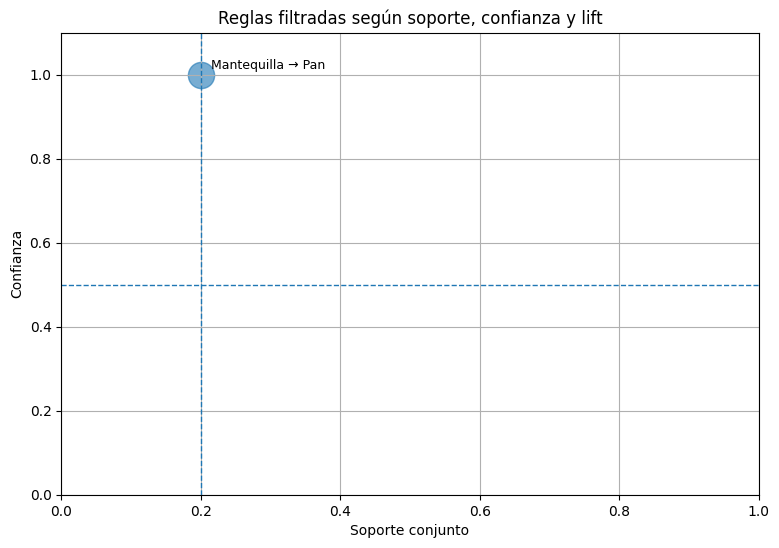

In [38]:
if reglas_filtradas.empty:
    print("No hay reglas que cumplan los filtros definidos.")
else:
    print(f"Cantidad de reglas filtradas: {len(reglas_filtradas)}")
    print("Cada punto representa una regla.")
    print("Eje X: soporte conjunto")
    print("Eje Y: confianza")
    print("Tamaño del punto: lift")

    plt.figure(figsize=(9, 6))

    x = reglas_filtradas["Soporte conjunto"]
    y = reglas_filtradas["Confianza"]
    sizes = reglas_filtradas["Lift"] * 250

    plt.scatter(x, y, s=sizes, alpha=0.6)

    for _, row in reglas_filtradas.iterrows():
        plt.text(
            row["Soporte conjunto"] + 0.015,
            row["Confianza"] + 0.015,
            row["Regla"],
            fontsize=9
        )

    plt.xlabel("Soporte conjunto")
    plt.ylabel("Confianza")
    plt.title("Reglas filtradas según soporte, confianza y lift")

    plt.xlim(0, 1)
    plt.ylim(0, 1.1)

    plt.axhline(y=confianza_minima, linestyle="--", linewidth=1)
    plt.axvline(x=soporte_conjunto_minimo, linestyle="--", linewidth=1)

    plt.grid(True)
    plt.show()

# Parte H: Herramientas

## 27. Herramientas usadas en esta área

Además de algoritmos y métricas, existen herramientas para implementar, explorar y visualizar reglas.

| Herramienta | Lenguaje | Uso principal |
|---|---|---|
| `mlxtend` | Python | Apriori, FP-Growth y reglas |
| `arules` | R | Minería de reglas de asociación |
| `arulesViz` | R | Visualización de reglas |
| `Ciboulette` | R | Exploración interactiva de reglas |

Punto importante:

> Ciboulette es una herramienta, no una métrica.

## 28. Resumen final

En este tutorial el foco estuvo en los modelos.

Los tres algoritmos principales fueron:

| Algoritmo | Idea central |
|---|---|
| Apriori | Genera candidatos y filtra por soporte |
| FP-Growth | Comprime transacciones para encontrar patrones frecuentes |
| Eclat | Usa representación vertical e intersecciones |

La idea más importante es:

```text
El algoritmo encuentra itemsets frecuentes.
Las reglas se generan después.
Las métricas evalúan las reglas.
Las herramientas ayudan a implementarlas o explorarlas.
```

Por eso no hay que mezclar:

- algoritmo;
- métrica;
- herramienta.

## 29. Actividades sugeridas

1. ¿Qué diferencia hay entre itemset frecuente y regla?
2. ¿Qué algoritmo es más fácil de entender inicialmente?
3. ¿Qué algoritmo usa una representación vertical?
4. ¿Por qué FP-Growth puede ser más eficiente que Apriori?
5. ¿Por qué no basta con encontrar itemsets frecuentes?
6. ¿Qué métrica usarías para comparar ambas direcciones de una regla?
7. ¿Por qué Ciboulette no es una métrica?
